In [60]:
# ============================================================
# UV EVALUATOR — DATASET B
# Модель для прогнозирования максимума UV-поглощения (λmax)
# ============================================================

In [61]:
!pip install rdkit -q

In [62]:
# ============================================================
# 1. УСТАНОВКА И ИМПОРТ ЗАВИСИМОСТЕЙ
# ============================================================
import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [63]:
# ============================================================
# 2. ЗАГРУЗКА ДАТАСЕТА B
# ============================================================
df = pd.read_csv("dataset_B_raw.csv")

print("Размер датасета:", df.shape)
df.head()

Размер датасета: (50, 6)


,SMILES,lambda_max,log_kp,chemical_family,source_id,compound_name
0,O=C(c1ccc(OC)cc1)c1ccccc1,310.0,-2.8,Benzophenone,U01_CosIng_UV,Methanone derivative
1,O=C(c1ccccc1)c1c(O)ccc(OC)c1,325.0,-2.6,Benzophenone,U01_CosIng_UV,Oxybenzone (Benzophenone-3)
2,O=C(c1ccc(S(=O)(=O)O)cc1)c1c(O)ccc(OC)c1,325.0,-3.8,Benzophenone,U01_CosIng_UV,Sulisobenzone (Benzophenone-4)
3,O=C(c1c(O)ccc(OC)c1)c1c(O)ccc(OC)c1,340.0,-2.7,Benzophenone,U01_CosIng_UV,Dioxybenzone (Benzophenone-8)
4,O=C(c1ccc(C(C)(C)C)cc1)CC(=O)c1ccc(OC)cc1,357.0,-2.4,Dibenzoylmethane,U01_CosIng_UV,Avobenzone (Butyl Methoxydibenzoylmethane)


In [64]:
print(df.columns.tolist())

['SMILES', 'lambda_max', 'log_kp', 'chemical_family', 'source_id', 'compound_name']


In [65]:
# ============================================================
# 3. ПЕРВИЧНЫЙ АНАЛИЗ И ПРЕДОБРАБОТКА ДАННЫХ
# ============================================================
print(df.info())

print("\nПропуски:")
print(df.isna().sum())

print("\nСтатистика lambda_max:")
print(df["lambda_max"].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   SMILES           50 non-null     object 
 1   lambda_max       50 non-null     float64
 2   log_kp           50 non-null     float64
 3   chemical_family  50 non-null     object 
 4   source_id        50 non-null     object 
 5   compound_name    50 non-null     object 
dtypes: float64(2), object(4)
memory usage: 2.5+ KB
None

Пропуски:
SMILES             0
lambda_max         0
log_kp             0
chemical_family    0
source_id          0
compound_name      0
dtype: int64

Статистика lambda_max:
count     50.000000
mean     327.940000
std       20.901528
min      295.000000
25%      310.000000
50%      326.500000
75%      344.250000
max      380.000000
Name: lambda_max, dtype: float64


In [66]:
uv_df = df[
    [
        "SMILES",
        "lambda_max",
        "chemical_family",
        "compound_name",
        "source_id"
    ]
].copy()

uv_df.head()

,SMILES,lambda_max,chemical_family,compound_name,source_id
0,O=C(c1ccc(OC)cc1)c1ccccc1,310.0,Benzophenone,Methanone derivative,U01_CosIng_UV
1,O=C(c1ccccc1)c1c(O)ccc(OC)c1,325.0,Benzophenone,Oxybenzone (Benzophenone-3),U01_CosIng_UV
2,O=C(c1ccc(S(=O)(=O)O)cc1)c1c(O)ccc(OC)c1,325.0,Benzophenone,Sulisobenzone (Benzophenone-4),U01_CosIng_UV
3,O=C(c1c(O)ccc(OC)c1)c1c(O)ccc(OC)c1,340.0,Benzophenone,Dioxybenzone (Benzophenone-8),U01_CosIng_UV
4,O=C(c1ccc(C(C)(C)C)cc1)CC(=O)c1ccc(OC)cc1,357.0,Dibenzoylmethane,Avobenzone (Butyl Methoxydibenzoylmethane),U01_CosIng_UV


In [67]:
# ============================================================
# 4. ПРОВЕРКА И КАНОНИЗАЦИЯ SMILES
# ============================================================
def is_valid_smiles(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    return mol is not None


uv_df["valid_smiles"] = uv_df["SMILES"].apply(is_valid_smiles)

print(uv_df["valid_smiles"].value_counts())

valid_smiles
True     49
False     1
Name: count, dtype: int64


[14:08:57] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[14:08:57] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8


In [68]:
invalid_rows = uv_df[
    ~uv_df["valid_smiles"]
]

invalid_rows

,SMILES,lambda_max,chemical_family,compound_name,source_id,valid_smiles
19,c1ccc2c(c1)nc(n2)c1c(O)ccc(C(C)(C)C)c1,345.0,Benzotriazole,Drometrizole derivative,U01_CosIng_UV,False


In [69]:
uv_df = uv_df[
    uv_df["valid_smiles"]
].copy()

print("Количество валидных записей:", len(uv_df))

Количество валидных записей: 49


In [70]:
def canonicalize_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    return Chem.MolToSmiles(
        mol,
        canonical=True
    )


uv_df["canonical_smiles"] = uv_df["SMILES"].apply(
    canonicalize_smiles
)

uv_df.head()
print("Всего записей:", len(uv_df))
print(
    "Уникальных молекул:",
    uv_df["canonical_smiles"].nunique()
)

Всего записей: 49
Уникальных молекул: 48


In [71]:
duplicates = uv_df[
    uv_df.duplicated(
        subset="canonical_smiles",
        keep=False
    )
].sort_values("canonical_smiles")

duplicates[
    [
        "compound_name",
        "canonical_smiles",
        "lambda_max",
        "source_id"
    ]
]

,compound_name,canonical_smiles,lambda_max,source_id
0,Methanone derivative,COc1ccc(C(=O)c2ccccc2)cc1,310.0,U01_CosIng_UV
15,Methoxybenzophenone,COc1ccc(C(=O)c2ccccc2)cc1,312.0,U01_CosIng_UV


In [72]:
X = np.array([
    smiles_to_fingerprint(smiles)
    for smiles in uv_unique["canonical_smiles"]
])

y = uv_unique["lambda_max"].to_numpy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (48, 2048)
y shape: (48,)


In [73]:
# ============================================================
# 5. ОБЪЕДИНЕНИЕ ДУБЛИКАТОВ
# ============================================================
uv_unique = (
    uv_df
    .groupby("canonical_smiles", as_index=False)
    .agg({
        "lambda_max": "mean",
        "chemical_family": "first",
        "compound_name": "first",
        "source_id": "first"
    })
)

print("Записей после объединения дублей:", len(uv_unique))

uv_unique.head()

Записей после объединения дублей: 48


,canonical_smiles,lambda_max,chemical_family,compound_name,source_id
0,CC(=O)c1ccc(NC(=O)c2ccccc2O)cc1,315.0,Salicylate,Salicylamide derivative,U01_CosIng_UV
1,CC(C)(C)c1cc(-n2nc3ccccc3n2)c(O)c(C(C)(C)C)c1,345.0,Benzotriazole,Tinuvin 328 proxy,U01_CosIng_UV
2,CC(C)(C)c1ccc(O)c(C(=O)c2ccccc2)c1,335.0,Benzophenone,tert-butyl hydroxybenzophenone,U01_CosIng_UV
3,CC(C)c1ccc(COC(=O)c2ccccc2O)cc1,310.0,Salicylate,Cuminyl salicylate,U01_CosIng_UV
4,CC1(C)C2CCC1(CS(=O)(=O)O)C(=O)C2=Cc1ccccc1,300.0,Camphor,Mexoryl SO proxy (Camphor sulfonic),U01_CosIng_UV


In [74]:
from sklearn.model_selection import KFold, cross_val_predict

In [75]:
# ============================================================
# 6. RANDOM FOREST — БАЗОВАЯ МОДЕЛЬ
# ============================================================
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [76]:
# ============================================================
# 7. 5-FOLD CROSS-VALIDATION
# ============================================================
from sklearn.model_selection import KFold, cross_val_predict

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_pred_cv = cross_val_predict(
    model,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

print("Cross-validation завершена!")
print("Количество предсказаний:", len(y_pred_cv))

Cross-validation завершена!
Количество предсказаний: 48


In [77]:
mae = mean_absolute_error(y, y_pred_cv)

rmse = np.sqrt(
    mean_squared_error(y, y_pred_cv)
)

r2 = r2_score(y, y_pred_cv)

print(f"MAE:  {mae:.2f} nm")
print(f"RMSE: {rmse:.2f} nm")
print(f"R²:   {r2:.3f}")

MAE:  13.87 nm
RMSE: 17.98 nm
R²:   0.255


In [78]:
baseline_prediction = np.full(
    len(y),
    np.mean(y)
)

baseline_mae = mean_absolute_error(
    y,
    baseline_prediction
)

print(f"Random Forest MAE: {mae:.2f} nm")
print(f"Mean baseline MAE: {baseline_mae:.2f} nm")

Random Forest MAE: 13.87 nm
Mean baseline MAE: 17.56 nm


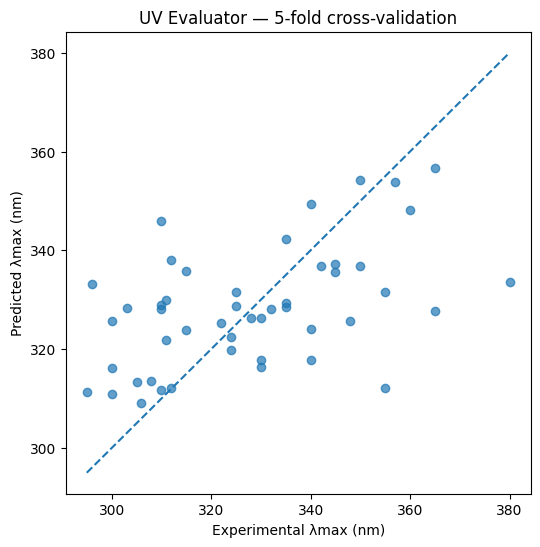

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.scatter(y, y_pred_cv, alpha=0.7)

minimum = min(y.min(), y_pred_cv.min())
maximum = max(y.max(), y_pred_cv.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "--"
)

plt.xlabel("Experimental λmax (nm)")
plt.ylabel("Predicted λmax (nm)")
plt.title("UV Evaluator — 5-fold cross-validation")

plt.show()